### Notebook 3 — Market Basket Analysis (MBA)
**Người phụ trách:** Trần Tấn Lực — 52400055 — Pattern Mining Lead

**Bộ dữ liệu:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

---

**Input:** `Data/Processed/Transactions_Clean.csv`

**Output:** `Data/Interim/Association_Rules_Result.csv`

---

**Mục lục:**
1. Đọc dữ liệu + Xây dựng ma trận One-hot.
2. Chạy Apriori - Chạy FP-Growth.
3. So sánh Apriori vs FP-Growth (Tốc độ, Số itemsets)
4. Thực nghiệm mở rộng — So sánh ở nhiều ngưỡng `min_support`
5. Sinh luật kết hợp kèm Kulczynski Measure.
6. Chọn Top luật có ý nghĩa nhất.
---

## 0. Chuẩn bị môi trường

In [2]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Xác định thư mục gốc project để Notebook có thể import Source/
PROJECT_NOW = Path.cwd()
if (PROJECT_NOW / "Source").exists():
    PROJECT_ROOT_TAM = PROJECT_NOW
else:
    PROJECT_ROOT_TAM = PROJECT_NOW.parent
sys.path.insert(0, str(PROJECT_ROOT_TAM))

from Source.Utils.IO import load_csv, save_to_csv, get_project_root, PROCESSED_DATA_DIR, INTERIM_DATA_DIR
from Source.Utils.Visualization import set_plot_style, save_current_figure, PRIMARY_COLOR, SECONDARY_COLOR
from Source.MBA.Association_Rules import (build_onehot_basket, run_apriori, run_fpgrowth, generate_rules, map_stockcode_to_description, format_rule_as_text,)

set_plot_style()
print(f"Thư mục gốc dự án: {get_project_root()}")

Thư mục gốc dự án: D:\Lilith\Customer-Analytics-for-E-Commerce


### 1. Đọc dữ liệu - Xây dựng ma trận One-hot

- Đọc `Transactions_Clean.csv`, file này vẫn còn các dòng thiếu `Customer ID`.

- Lọc thêm 1 điều kiện: `Quantity > 0`.

In [3]:
transactions_clean = load_csv(PROCESSED_DATA_DIR / "Transactions_Clean.csv", date_columns=["InvoiceDate"],)

print(f"Số dòng đọc vào: {len(transactions_clean):,}")

# Chỉ giữ các dòng có Quantity > 0, cần sử dụng các giao dịch mua thực sự cho MBA
transactions_for_mba = transactions_clean[transactions_clean["Quantity"] > 0].copy()

print(f"Số dòng dùng cho MBA (Quantity > 0): {len(transactions_for_mba):,}")
print(f"Số hoá đơn (Invoice) duy nhất: {transactions_for_mba['Invoice'].nunique():,}")
print(f"Số sản phẩm (StockCode) duy nhất: {transactions_for_mba['StockCode'].nunique():,}")

Số dòng đọc vào: 1,006,013
Số dòng dùng cho MBA (Quantity > 0): 1,006,013
Số hoá đơn (Invoice) duy nhất: 41,383
Số sản phẩm (StockCode) duy nhất: 4,971


In [4]:
# Xây dựng ma trận One-hot basket

onehot_basket = build_onehot_basket(transactions_for_mba, invoice_col="Invoice", item_col="StockCode",)

# Tổng số giao dịch (Invoice) trong ma trận one-hot
n_transactions = onehot_basket.shape[0]

# Xem nhanh 5 Invoice đầu tiên và 8 sản phẩm đầu tiên
onehot_basket.iloc[:5, :8]

[Build Onehot Basket] Số hoá đơn (giỏ hàng): 41,383
[Build Onehot Basket] Kích thước ma trận Onehot: (41383, 4971)


,10002,10002R,10080,10109,10120,10123C,10123G,10124A
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


### 2. Chạy Apriori và FP-Growth

In [5]:
# Chạy Apriori
MIN_SUPPORT = 0.02

print("Chạy Apriori ta thu được: ")

itemsets_apriori, time_apriori = run_apriori(onehot_basket, min_support=MIN_SUPPORT)

Chạy Apriori ta thu được: 
[Run Apriori] Min Support = 0.02: tìm được 290 Frequent Itemsets trong 0.95 giây.


In [6]:
print("Chạy FP-Growth ta thu được: ")
itemsets_fpgrowth, time_fpgrowth = run_fpgrowth(onehot_basket, min_support=MIN_SUPPORT)

Chạy FP-Growth ta thu được: 
[Run FP-Growth] Min Support = 0.02: tìm được 290 Frequent Itemsets trong 2.43 giây.


### 3. So sánh Apriori và FP-Growth

Phần này thực hiện 2 việc:
- **Kiểm chứng tính đúng đắn:** 2 thuật toán phải tìm ra cùng số lượng Frequent Itemsets, vì cùng giải 1 bài toán, chỉ khác cách tìm.

- **So sánh hiệu năng ở nhiều ngưỡng `min_support` khác nhau**, không chỉ đo 1 điểm duy nhất, vì điểm mạnh yếu của mỗi thuật toán chỉ bộc lộ rõ khi ngưỡng support thay đổi.

In [12]:
comparison_table = pd.DataFrame({
    "Thuật toán": ["Apriori", "FP-Growth"],
    "Số Frequent Itemsets": [len(itemsets_apriori), len(itemsets_fpgrowth)],
    "Thời gian chạy (giây)": [round(time_apriori, 3), round(time_fpgrowth, 3)],
})
comparison_table

,Thuật toán,Số Frequent Itemsets,Thời gian chạy (giây)
0,Apriori,290,0.949
1,FP-Growth,290,2.435


### 4. Thực nghiệm mở rộng — So sánh ở nhiều ngưỡng `min_support`

In [13]:
# Benchmark Apriori và FP-Growth ở nhiều min_support
SUPPORT_THRESHOLDS = [0.02, 0.01, 0.005]

benchmark_results = []

for support_threshold in SUPPORT_THRESHOLDS:

    print(f"\n Đang chạy với min_support = {support_threshold}")
    
    apriori_itemsets, apriori_elapsed = run_apriori(onehot_basket, min_support=support_threshold,)
    fpgrowth_itemsets, fpgrowth_elapsed = run_fpgrowth(onehot_basket, min_support=support_threshold,)

    # Kiểm tra tính nhất quán giữa hai thuật toán
    if len(apriori_itemsets) != len(fpgrowth_itemsets):
        raise ValueError(
            f"Không khớp số Frequent Itemsets tại "
            f"min_support = {support_threshold}: "
            f"Apriori = {len(apriori_itemsets)}, "
            f"FP-Growth = {len(fpgrowth_itemsets)}."
        )

    benchmark_results.append({
        "min_support": support_threshold,
        "Số Itemsets": len(apriori_itemsets),
        "Apriori (giây)": round(apriori_elapsed, 2),
        "FP-Growth (giây)": round(fpgrowth_elapsed, 2),
        "Tỷ lệ FP-Growth / Apriori": round(
            fpgrowth_elapsed / apriori_elapsed,
            2,
        ),
    })

benchmark_table = pd.DataFrame(benchmark_results)
benchmark_table


 Đang chạy với min_support = 0.02
[Run Apriori] Min Support = 0.02: tìm được 290 Frequent Itemsets trong 0.97 giây.
[Run FP-Growth] Min Support = 0.02: tìm được 290 Frequent Itemsets trong 3.00 giây.

 Đang chạy với min_support = 0.01
[Run Apriori] Min Support = 0.01: tìm được 1,223 Frequent Itemsets trong 5.33 giây.
[Run FP-Growth] Min Support = 0.01: tìm được 1,223 Frequent Itemsets trong 6.45 giây.

 Đang chạy với min_support = 0.005
[Run Apriori] Min Support = 0.005: tìm được 6,863 Frequent Itemsets trong 21.65 giây.
[Run FP-Growth] Min Support = 0.005: tìm được 6,863 Frequent Itemsets trong 13.10 giây.


,min_support,Số Itemsets,Apriori (giây),FP-Growth (giây),Tỷ lệ FP-Growth / Apriori
0,0.020,290,0.97,3.00,3.10
1,0.010,1223,5.33,6.45,1.21
2,0.005,6863,21.65,13.10,0.61


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\4. Apriori vs FPGrowth Benchmark.png


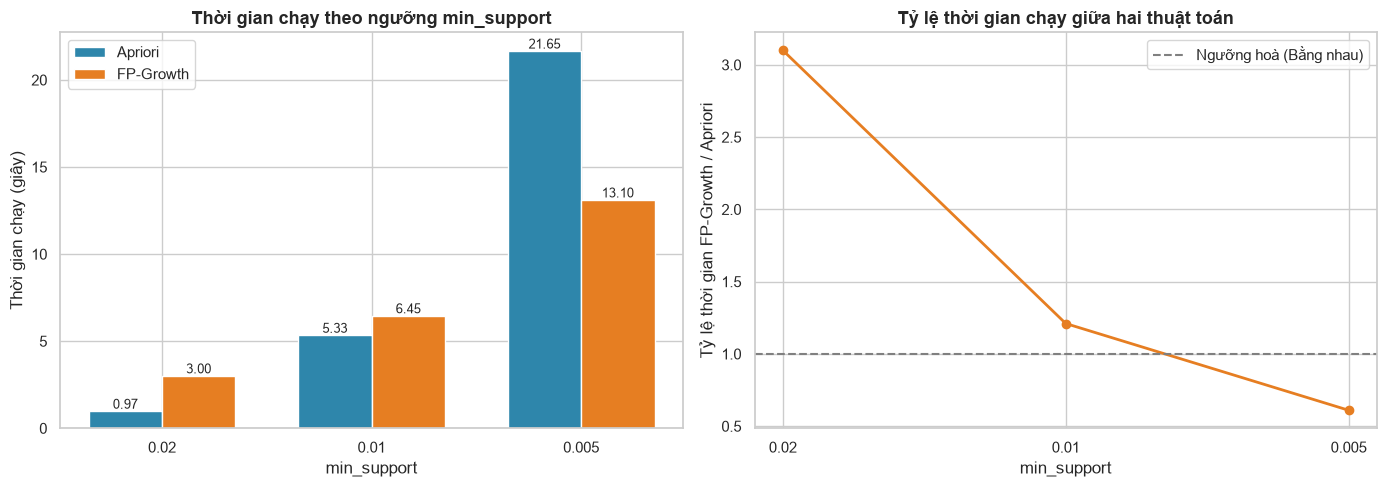

In [38]:
# Trực quan hóa kết quả benchmark Apriori vs FP-Growth

fig, (ax_time, ax_ratio) = plt.subplots(1, 2, figsize=(14, 5),)

support_labels = [str(support) for support in benchmark_table["min_support"]]
support_positions = range(len(support_labels))
bar_width = 0.35


# Biểu đồ 1: Thời gian chạy
ax_time.bar([p - bar_width / 2 for p in support_positions], benchmark_table["Apriori (giây)"],
            width=bar_width, label="Apriori", color=PRIMARY_COLOR,)

ax_time.bar([p + bar_width / 2 for p in support_positions], benchmark_table["FP-Growth (giây)"], 
            width=bar_width, label="FP-Growth", color=SECONDARY_COLOR,)

# Hiển thị chỉ số trên cột Apriori
bars_apriori = ax_time.containers[0]
for bar in bars_apriori:
    height = bar.get_height()
    ax_time.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom", fontsize=9)

# Hiển thị chỉ số trên cột FP-Growth
bars_fpgrowth = ax_time.containers[1]
for bar in bars_fpgrowth:
    height = bar.get_height()
    ax_time.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom", fontsize=9)

ax_time.set_xticks(list(support_positions))
ax_time.set_xticklabels(support_labels)

ax_time.set_xlabel("min_support")
ax_time.set_ylabel("Thời gian chạy (giây)")
ax_time.set_title("Thời gian chạy theo ngưỡng min_support")
ax_time.legend()


# Biểu đồ 2: Tỷ lệ thời gian FP-Growth / Apriori
ax_ratio.plot(support_labels, benchmark_table["Tỷ lệ FP-Growth / Apriori"], 
              marker="o", color=SECONDARY_COLOR, linewidth=2,)

ax_ratio.axhline(y=1.0, color="gray", linestyle="--", label="Ngưỡng hoà (Bằng nhau)",)

ax_ratio.set_xlabel("min_support")
ax_ratio.set_ylabel("Tỷ lệ thời gian FP-Growth / Apriori")
ax_ratio.set_title("Tỷ lệ thời gian chạy giữa hai thuật toán")
ax_ratio.legend()

plt.tight_layout()
save_current_figure("4. Apriori vs FPGrowth Benchmark.png")
plt.show()

### **Nhận xét**

- **Quan sát thực tế:** Kết quả Benchmark trên bộ dữ liệu này cho thấy **không có thuật toán nào nhanh hơn ở mọi ngưỡng `min_support`**. Ở `min_support = 0.02`, Apriori chạy trong **0.97 giây**, nhanh hơn FP-Growth (**2.37 giây**). Ở `min_support = 0.01`, Apriori tiếp tục nhanh hơn (**5.16 giây** so với **6.03 giây**). Tuy nhiên, khi giảm xuống `min_support = 0.005`, FP-Growth trở nên nhanh hơn với **14.72 giây**, trong khi Apriori mất **22.01 giây**. Đồng thời, cả hai thuật toán đều tìm được cùng số lượng Frequent Itemsets tại cả 3 ngưỡng: **290, 1,223 và 6,863** tương ứng.

- Sự khác biệt này cho thấy hiệu năng thực tế không thể suy ra chỉ từ độ phức tạp lý thuyết của thuật toán. `mlxtend` triển khai Apriori với nhiều phép toán trên ma trận và có tùy chọn `low_memory = True` để giảm yêu cầu bộ nhớ, trong khi FP-Growth sử dụng cấu trúc FP-Tree để khai thác các mẫu phổ biến. Cách biểu diễn dữ liệu, chi phí tạo và xử lý cấu trúc trung gian, cùng với cách cài đặt cụ thể của thư viện đều có thể ảnh hưởng đến thời gian chạy. Vì vậy, việc FP-Growth có lợi thế về mặt thuật toán không có nghĩa nó sẽ luôn chạy nhanh hơn Apriori trên mọi bộ dữ liệu và mọi ngưỡng.

- **Xu hướng theo `min_support`:** Khi giảm `min_support` từ **0.02 → 0.01 → 0.005**, số Frequent Itemsets tăng mạnh từ **290 → 1,223 → 6,863**, đồng thời bài toán trở nên nặng hơn đối với cả hai thuật toán. Đáng chú ý, tỷ lệ thời gian **FP-Growth / Apriori** thay đổi từ khoảng **2.44 → 1.17 → 0.67**, cho thấy lợi thế về thời gian chuyển từ Apriori sang FP-Growth khi ngưỡng support giảm. Kết quả này phù hợp với việc FP-Growth có thể phát huy lợi thế hơn khi không gian tìm kiếm trở nên lớn.

- **Tóm lại:** Nhóm sử dụng **FP-Growth** cho các bước sinh luật tiếp theo. Quyết định này không dựa trên giả định rằng FP-Growth luôn nhanh hơn, mà dựa trên kết quả Benchmark cụ thể: tại ngưỡng `min_support = 0.005`, FP-Growth chạy nhanh hơn Apriori, đồng thời hai thuật toán cho kết quả Frequent Itemsets giống nhau ở các ngưỡng đã kiểm thử. Kết quả thực nghiệm cũng cho thấy hiệu năng cần được **đo trực tiếp trên từng bộ dữ liệu, ngưỡng support và cấu hình thư viện**.

### 5. Sinh luật kết hợp kèm Kulczynski Measure

In [39]:
# Sinh luật kết hợp từ Frequent Itemsets của FP-Growth
rules = generate_rules(fpgrowth_itemsets, n_transactions)

def format_stockcodes(itemset):
    return " + ".join(sorted(str(code) for code in itemset))

# Tạo bản sao chỉ để hiển thị
rules_display = rules.copy()

rules_display["Antecedents"] = rules_display["antecedents"].apply(format_stockcodes)
rules_display["Consequents"] = rules_display["consequents"].apply(format_stockcodes)

rules_display = rules_display[["Antecedents", "Consequents", "support", "confidence", "lift", "kulczynski",]
                              ].rename(
                                  columns={
                                      "support": "Support",
                                      "confidence": "Confidence",
                                      "lift": "Lift",
                                      "kulczynski": "Kulczynski",
                                      }
                                  )

rules_display.head(6)

[Generate Rules] Sinh được 8,777 luật kết hợp  (Lọc theo confidence >= 0.3).


,Antecedents,Consequents,Support,Confidence,Lift,Kulczynski
0,21232,85123A,0.018003,0.305955,2.357350,0.222331
1,21212 + 85123A,21232,0.006404,0.363512,6.177907,0.236171
2,21212 + 21232,85123A,0.006404,0.416667,3.210374,0.233003
3,21232 + 85123A,21212,0.006404,0.355705,4.721016,0.220348
4,21232 + 85123A,85099B,0.006259,0.347651,3.602114,0.206249
5,21232 + 85099B,85123A,0.006259,0.459220,3.538242,0.253721


**Nhận xét về ý nghĩa Kulczynski:** Giá trị Kulczynski nằm trong khoảng **[0, 1]** và được tính bằng trung bình cộng của `confidence(A→B)` và `confidence(B→A)`. Do đó, đây là một độ đo **đối xứng**, giúp đánh giá mức độ liên kết của hai sản phẩm theo **cả hai chiều** thay vì chỉ nhìn vào một hướng của luật. Kulczynski cũng có tính **null-invariant**, nghĩa là kết quả không bị chi phối bởi số lượng giao dịch không chứa cả hai sản phẩm.

Vì vậy, một luật có `Lift` cao nhưng `Kulczynski` thấp có thể cho thấy mối quan hệ giữa hai sản phẩm **không cân bằng giữa hai chiều**; khi đó không nên chỉ dựa vào `Lift` để đánh giá mức độ liên kết. Kulczynski nên được sử dụng **bổ sung cùng `Support`, `Confidence` và `Lift`**, thay vì xem nó là thước đo thay thế hoàn toàn cho `Lift`.


### 6. Chọn Top luật có ý nghĩa nhất

In [40]:
# Chọn Top 7 Association Rules và diễn giải

# Tạo dictionary ánh xạ StockCode → Description
code_to_name = map_stockcode_to_description(transactions_for_mba)

# Các luật đã được lọc confidence >= MIN_CONFIDENCE ở bước 5.
# Tại đây sắp xếp theo Lift giảm dần để chọn 7 luật có mức
# liên kết tương đối cao nhất trong tập luật hiện tại.
top_rules = (rules.sort_values("lift", ascending=False).head(7).reset_index(drop=True))

print(
    "TOP 7 LUẬT KẾT HỢP CÓ LIFT CAO NHẤT:\n"
)

for idx, row in top_rules.iterrows():

    rule_text = format_rule_as_text(row, code_to_name)
    print(f"{idx + 1}. {rule_text}")

    print(
        f"   Support = {row['support']:.4f}  |  "
        f"Confidence = {row['confidence']:.3f}  |  "
        f"Lift = {row['lift']:.2f}  |  "
        f"Kulczynski = {row['kulczynski']:.3f}\n"
    )

TOP 7 LUẬT KẾT HỢP CÓ LIFT CAO NHẤT:

1. Khách mua [CHILDS GARDEN TROWEL PINK, CHILDS GARDEN FORK BLUE ] thường mua kèm [CHILDS GARDEN FORK PINK, CHILDS GARDEN TROWEL BLUE ]
   Support = 0.0051  |  Confidence = 0.918  |  Lift = 157.65  |  Kulczynski = 0.901

2. Khách mua [CHILDS GARDEN FORK PINK, CHILDS GARDEN TROWEL BLUE ] thường mua kèm [CHILDS GARDEN TROWEL PINK, CHILDS GARDEN FORK BLUE ]
   Support = 0.0051  |  Confidence = 0.884  |  Lift = 157.65  |  Kulczynski = 0.901

3. Khách mua [HERB MARKER PARSLEY, HERB MARKER ROSEMARY] thường mua kèm [HERB MARKER THYME]
   Support = 0.0051  |  Confidence = 0.947  |  Lift = 157.33  |  Kulczynski = 0.901

4. Khách mua [HERB MARKER THYME] thường mua kèm [HERB MARKER PARSLEY, HERB MARKER ROSEMARY]
   Support = 0.0051  |  Confidence = 0.855  |  Lift = 157.33  |  Kulczynski = 0.901

5. Khách mua [HERB MARKER ROSEMARY] thường mua kèm [HERB MARKER THYME, HERB MARKER PARSLEY]
   Support = 0.0051  |  Confidence = 0.845  |  Lift = 156.15  |  Kulczynsk

Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\5. Top 7 Association Rules.png


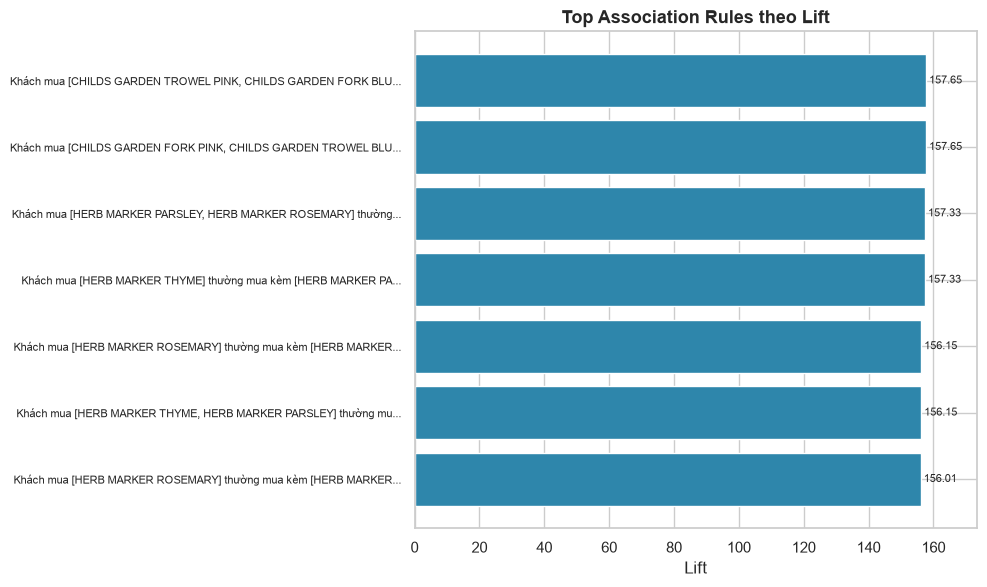

In [41]:
# Trực quan hóa Top Association Rules theo Lift
fig, ax = plt.subplots(figsize=(10, 6))
rule_labels = []

for _, row in top_rules.iterrows():
    rule_text = format_rule_as_text(row, code_to_name)

    if len(rule_text) > 60:
        rule_text = rule_text[:60] + "..."

    rule_labels.append(rule_text)

bars = ax.barh(range(len(top_rules)), top_rules["lift"], color=PRIMARY_COLOR)

ax.set_yticks(range(len(top_rules)))
ax.set_yticklabels(rule_labels,fontsize=8)

ax.invert_yaxis()

ax.set_xlabel("Lift")
ax.set_title("Top Association Rules theo Lift")

max_lift = top_rules["lift"].max()
ax.set_xlim(0, max_lift * 1.10)

# Hiển thị giá trị Lift trên từng thanh
for bar, lift_value in zip(bars, top_rules["lift"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{lift_value:.2f}", va="center", fontsize=8,)

plt.tight_layout()
save_current_figure("5. Top 7 Association Rules.png")

plt.show()

In [ ]:
# Xuất toàn bộ Association Rules ra file CSV

# Tạo bản sao riêng để export
rules_export = rules.copy()

# Thêm tên sản phẩm dễ đọc
rules_export["antecedents_name"] = rules_export[
    "antecedents"
].apply(
    lambda codes: ", ".join(code_to_name.get(str(code), str(code)) for code in sorted(codes, key=lambda x: str(x)))
)

rules_export["consequents_name"] = rules_export[
    "consequents"
].apply(
    lambda codes: ", ".join(
        code_to_name.get(str(code), str(code))
        for code in sorted(codes, key=lambda x: str(x))
    )
)

# Chuyển frozenset thành chuỗi để lưu CSV
rules_export["antecedents"] = rules_export[
    "antecedents"
].apply(
    lambda codes: ", ".join(
        sorted(str(code) for code in codes)
    )
)

rules_export["consequents"] = rules_export[
    "consequents"
].apply(
    lambda codes: ", ".join(
        sorted(str(code) for code in codes)
    )
)

# Chỉ giữ các cột cần bàn giao
export_columns = ["antecedents", "antecedents_name", "consequents", "consequents_name", "support", "confidence", "lift", "kulczynski",]

rules_export = (rules_export[export_columns].sort_values("lift", ascending=False).reset_index(drop=True))

rules_export = rules_export.rename(
    columns={
        "antecedents": "Antecedents",
        "antecedents_name": "Antecedents Name",
        "consequents": "Consequents",
        "consequents_name": "Consequents Name",
        "support": "Support",
        "confidence": "Confidence",
        "lift": "Lift",
        "kulczynski": "Kulczynski",
    }
)

save_to_csv(rules_export, INTERIM_DATA_DIR / "Association_Rules_Result.csv")

Đã lưu file: D:\Lilith\Customer-Analytics-for-E-Commerce\Data\Interim\Association_Rules_Result.csv  (Số dòng: 8,777 | Số cột: 8)
